# 🎯INFORME ANUAL 2025 DE LA FLOTA ACTIVA (GRUPO DE EMPRESAS A Y B) 🚛

Con el siguiente informe, la empresa A y la empresa B,pertenecientes a la misma firma, analizan los datos registrados durante el año 2025 sobre su flota activa de vehículos/camiones/maquinarias. Esto permite, la toma de decisiones estratégicas para la renovación de flota y optimización de costos logísticos en el siguiente año, mediante el análisis de tres indicadores claves:

1. ✅  ¿Cuáles son los 5 camiones/vehículos/maquinaria que más kilometros recorrieron en el tiempo analizado?
2.  ✅ ¿Que  camión/vehículo/maquinaria consumió más combustible?
3.  ✅ ¿Cuál fue el mes en el que se recorrió más kilometros con la flota completa?


# Carga de datos 🔔

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.__version__

'2.2.3'

In [40]:
df_log = pd.read_excel('estadisticas_flota_2025.xlsx')
df_log

,Vehiculo,Flota,Mes,Recorrido (km),Combustible (lts),Consumo,Vel. Max.
0,016DPV (DPV16),EMPRESA A,1,7.0,1.4,19.7 lts/100km,16 Km/Hs.
1,027DFK ( DFK27),EMPRESA A,1,0.0,0.0,0 lts/100km,0 Km/Hs.
2,032DBV (),EMPRESA A,1,0.5,0.1,24.1 lts/100km,7 Km/Hs.
3,047DLU (),EMPRESA A,1,0.0,0.0,0 lts/100km,0 Km/Hs.
4,083DFK (),EMPRESA B,1,0.0,0.0,0 lts/100km,0 Km/Hs.
...,...,...,...,...,...,...,...
571,LJN640 (),EMPRESA A,12,849.2,105.3,12.4 lts/100km,96 Km/Hs.
572,MFH852 (),EMPRESA A,12,1324.8,162.6,12.3 lts/100km,94 Km/Hs.
573,MFH853 (),EMPRESA A,12,2615.9,329.0,12.6 lts/100km,83 Km/Hs.
574,MRJ046 (),EMPRESA B,12,618.0,363.5,58.8 lts/100km,68 Km/Hs.


# Inspección de datos 🔧

In [41]:
df_log.describe()

,Mes,Recorrido (km),Combustible (lts)
count,576.000000,576.000000,576.000000
mean,6.500000,1455.135243,417.982465
std,3.455053,1993.286141,728.275037
min,1.000000,0.000000,0.000000
25%,3.750000,11.900000,2.300000
50%,6.500000,779.050000,133.300000
75%,9.250000,2308.225000,450.075000
max,12.000000,11404.300000,4668.600000


Información referente, el promedio y los valores máximos de km y combustibles




In [42]:
df_log.shape

(576, 7)

In [43]:
df_log.dtypes

,0
Vehiculo,object
Flota,object
Mes,int64
Recorrido (km),float64
Combustible (lts),float64
Consumo,object
Vel. Max.,object


In [44]:
df_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Vehiculo           576 non-null    object 
 1   Flota              576 non-null    object 
 2   Mes                576 non-null    int64  
 3   Recorrido (km)     576 non-null    float64
 4   Combustible (lts)  576 non-null    float64
 5   Consumo            576 non-null    object 
 6   Vel. Max.          576 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 31.6+ KB


# Transformación de datos ✨

In [45]:
df_log = df_log.drop(columns=['Consumo','Vel. Max.'], errors='ignore')
df_log

,Vehiculo,Flota,Mes,Recorrido (km),Combustible (lts)
0,016DPV (DPV16),EMPRESA A,1,7.0,1.4
1,027DFK ( DFK27),EMPRESA A,1,0.0,0.0
2,032DBV (),EMPRESA A,1,0.5,0.1
3,047DLU (),EMPRESA A,1,0.0,0.0
4,083DFK (),EMPRESA B,1,0.0,0.0
...,...,...,...,...,...
571,LJN640 (),EMPRESA A,12,849.2,105.3
572,MFH852 (),EMPRESA A,12,1324.8,162.6
573,MFH853 (),EMPRESA A,12,2615.9,329.0
574,MRJ046 (),EMPRESA B,12,618.0,363.5


Elimino estas columnas ya que su información no es relevante para el análisis

In [46]:
df_log = df_log.rename(columns={'Flota': 'Empresa'})
df_log

,Vehiculo,Empresa,Mes,Recorrido (km),Combustible (lts)
0,016DPV (DPV16),EMPRESA A,1,7.0,1.4
1,027DFK ( DFK27),EMPRESA A,1,0.0,0.0
2,032DBV (),EMPRESA A,1,0.5,0.1
3,047DLU (),EMPRESA A,1,0.0,0.0
4,083DFK (),EMPRESA B,1,0.0,0.0
...,...,...,...,...,...
571,LJN640 (),EMPRESA A,12,849.2,105.3
572,MFH852 (),EMPRESA A,12,1324.8,162.6
573,MFH853 (),EMPRESA A,12,2615.9,329.0
574,MRJ046 (),EMPRESA B,12,618.0,363.5


Modifico el nombre de la columna para obtener una referencia más clara de los datos.

In [47]:
month_mapping = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}
df_log['Mes'] = df_log['Mes'].map(month_mapping)
df_log

,Vehiculo,Empresa,Mes,Recorrido (km),Combustible (lts)
0,016DPV (DPV16),EMPRESA A,Enero,7.0,1.4
1,027DFK ( DFK27),EMPRESA A,Enero,0.0,0.0
2,032DBV (),EMPRESA A,Enero,0.5,0.1
3,047DLU (),EMPRESA A,Enero,0.0,0.0
4,083DFK (),EMPRESA B,Enero,0.0,0.0
...,...,...,...,...,...
571,LJN640 (),EMPRESA A,Diciembre,849.2,105.3
572,MFH852 (),EMPRESA A,Diciembre,1324.8,162.6
573,MFH853 (),EMPRESA A,Diciembre,2615.9,329.0
574,MRJ046 (),EMPRESA B,Diciembre,618.0,363.5


Se cambia el tipo de dato de la columna mes para obtener un mejor análisis.

# Limpieza de datos 🧹

In [48]:
df_log['Vehiculo'] = df_log['Vehiculo'].str.replace(r'\s*\([^)]*\)', '', regex=True)
df_log

,Vehiculo,Empresa,Mes,Recorrido (km),Combustible (lts)
0,016DPV,EMPRESA A,Enero,7.0,1.4
1,027DFK,EMPRESA A,Enero,0.0,0.0
2,032DBV,EMPRESA A,Enero,0.5,0.1
3,047DLU,EMPRESA A,Enero,0.0,0.0
4,083DFK,EMPRESA B,Enero,0.0,0.0
...,...,...,...,...,...
571,LJN640,EMPRESA A,Diciembre,849.2,105.3
572,MFH852,EMPRESA A,Diciembre,1324.8,162.6
573,MFH853,EMPRESA A,Diciembre,2615.9,329.0
574,MRJ046,EMPRESA B,Diciembre,618.0,363.5


Elimino datos dentro de los parentesis y los parentesis ya que no pertenecen al dominio del vehículo.

# 💹 Visualización de datos🚦

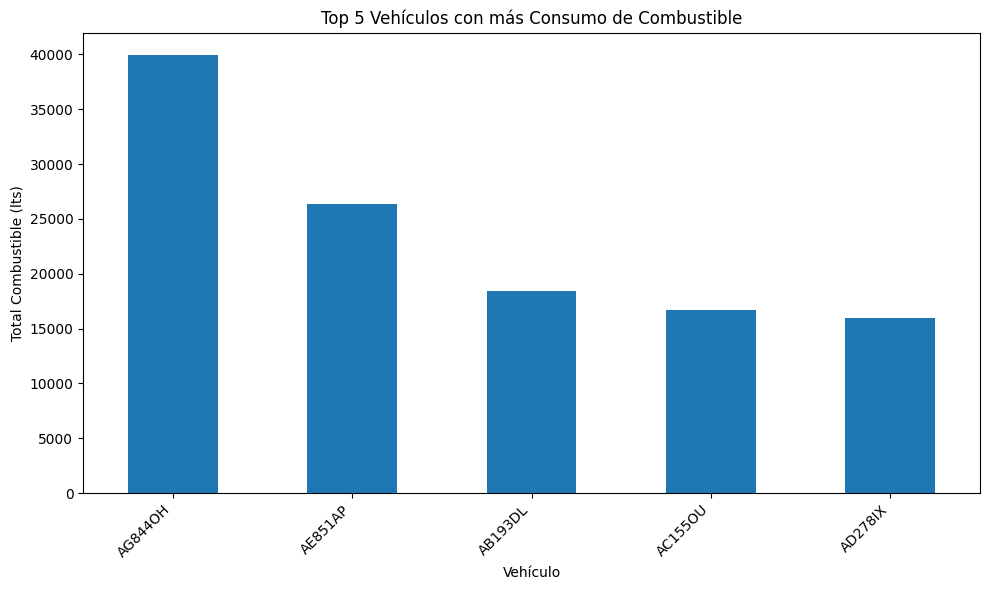

In [49]:
# Se calcula los 5 vehículos con más consumo de combustible.
top_5_vehiculos_consumo = df_log.groupby('Vehiculo')['Combustible (lts)'].sum().nlargest(5)

# Se proyecta en gráfico de barras
top_5_vehiculos_consumo.plot(kind='bar', figsize=(10, 6))
plt.title('Top 5 Vehículos con más Consumo de Combustible')
plt.xlabel('Vehículo')
plt.ylabel('Total Combustible (lts)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Auditoria en el rendimiento del consumo del equipo.

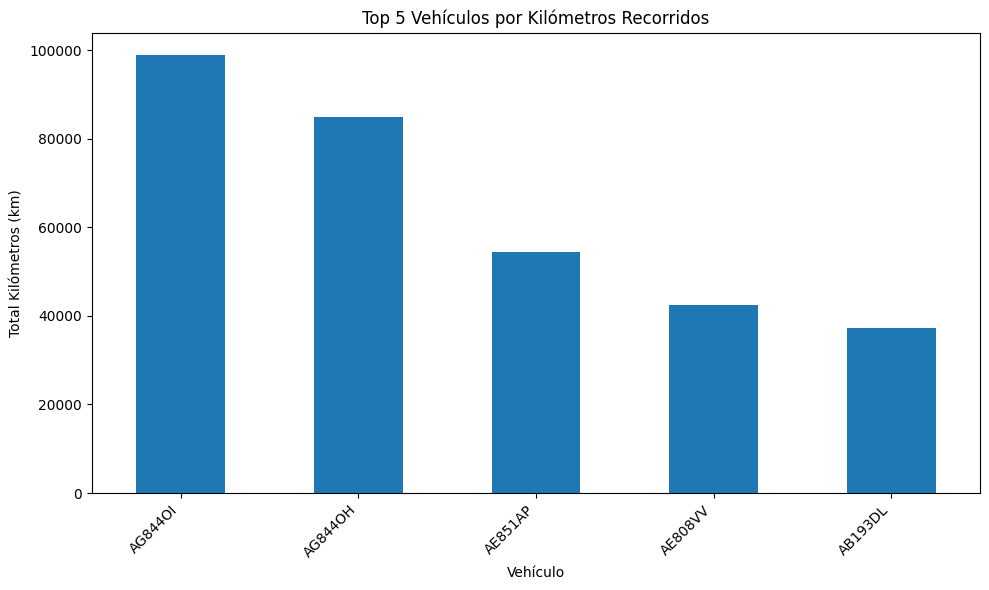

In [50]:
# Primero se calculó los 5 vehículos con más kilometros recorridos
top_5_vehiculos_km = df_log.groupby('Vehiculo')['Recorrido (km)'].sum().nlargest(5)

# Se proyecta en gráfico de barras
top_5_vehiculos_km.plot(kind='bar', figsize=(10, 6))
plt.title('Top 5 Vehículos por Kilómetros Recorridos')
plt.xlabel('Vehículo')
plt.ylabel('Total Kilómetros (km)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Prevención de desgastes mecánicos para determinar renovaciones de equipos.

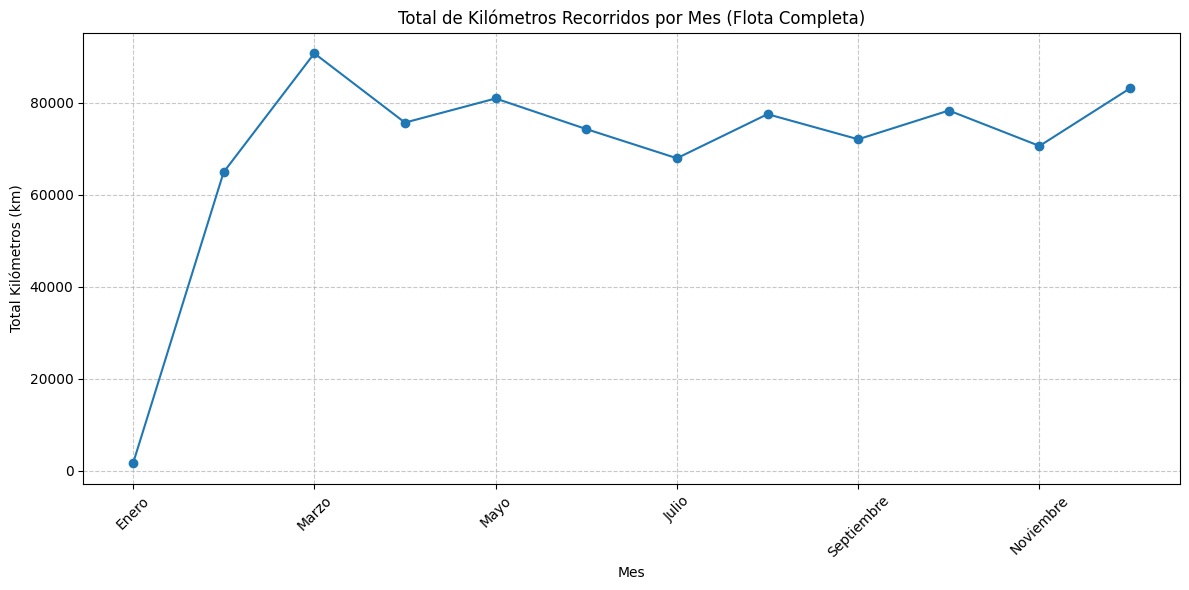

In [51]:
# Se crea un listado de los meses
mes_orden = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
               'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

# Se agrupan los datos de la columna 'Mes' y se suman los datos de 'Recorrido (km)'
mensual_km = df_log.groupby('Mes')['Recorrido (km)'].sum().reindex(mes_orden)

# Se proyecta en gráfico de línea
plt.figure(figsize=(12, 6))
mensual_km.plot(kind='line', marker='o')
plt.title('Total de Kilómetros Recorridos por Mes (Flota Completa)')
plt.xlabel('Mes')
plt.ylabel('Total Kilómetros (km)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se busca optimizar la asignación de recursos en los periodos de mayor demanda